# RFM 用户分层

**RFM 模型**（用户运营经典模型）：
- **R**（Recency 近度）：最近一次活跃距今越近越好
- **F**（Frequency 频度）：行为次数越多越好
- **M**（Monetary 价值）：消费金额越高越好

**本数据的口径声明**：
- M：数据无金额字段 → 用购买次数代理价值（行为数据场景的通行做法）
- R：数据无真实"今天" → 用距窗口末日（12-03）的天数代替
- F：行为总次数

**打分方法**：每维度按中位数切高/低（高于中位数=1），组合成 8 类用户。

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

url = URL.create(
    "mysql+pymysql",
    username="root",
    password=os.environ["MYSQL_PASSWORD"],
    host="localhost",
    port=3306,
    database="taobao_analysis",
    query={"charset": "utf8mb4"},
)
engine = create_engine(url)
print("连接成功 ✅")

连接成功 ✅


## 第 1 步：SQL 算出每个用户的 R/F/M

> ⚠️ pandas 里 SQL 的 `%` 要双写 `%%`

In [2]:
rfm = pd.read_sql(
    """
    SELECT user_id,
           DATEDIFF('2017-12-03', MAX(FROM_UNIXTIME(ts,'%%Y-%%m-%%d'))) AS recency,
           COUNT(*) AS frequency,
           SUM(CASE WHEN behavior_type='buy' THEN 1 ELSE 0 END) AS monetary
    FROM user_behavior
    GROUP BY user_id
    """,
    con=engine,
)
rfm.head()

,user_id,recency,frequency,monetary
0,1,0,55,0.0
1,100,0,98,8.0
2,1000,0,81,0.0
3,1000001,0,35,1.0
4,1000004,0,129,0.0


## 第 2 步：分箱前先看分布

先检查分布再决定分箱方式。注意 recency 的分布——窗口末日恰为大促日，大量用户的 R=0。

In [3]:
rfm[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,983.000000,983.000000,983.000000
mean,0.021363,101.729400,2.137335
std,0.182066,90.647467,3.097279
min,0.000000,4.000000,0.000000
25%,0.000000,37.500000,0.000000
50%,0.000000,74.000000,1.000000
75%,0.000000,136.000000,3.000000
max,4.000000,539.000000,43.000000


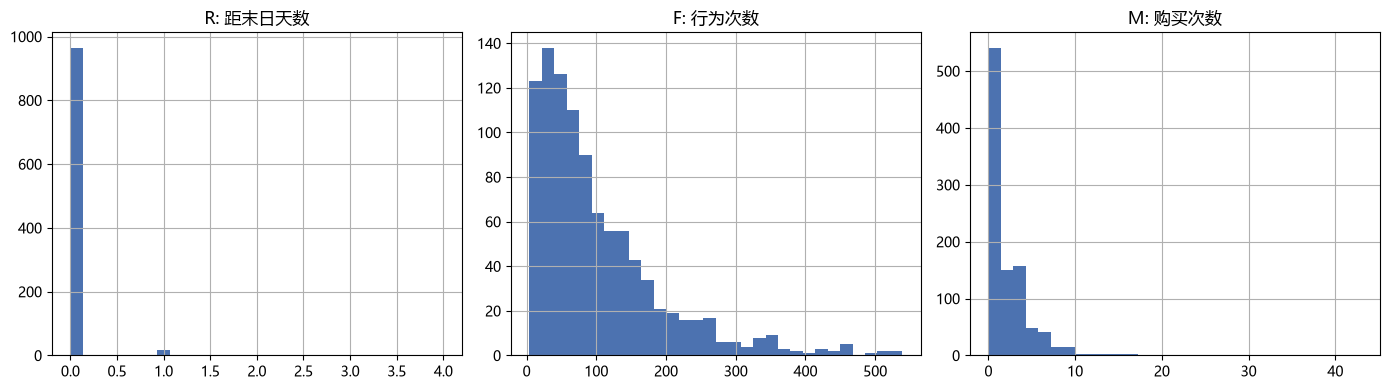

In [4]:
# 三个维度的直方图
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ['recency', 'frequency', 'monetary'],
                          ['R: 距末日天数', 'F: 行为次数', 'M: 购买次数']):
    rfm[col].hist(bins=30, ax=ax, color='#4C72B0')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 第 3 步：中位数打分 + 8 类映射

In [5]:
# 打分：R 越小越好（<= 中位数 = 高），F/M 越大越好（>= 中位数 = 高）
r = (rfm['recency'] <= rfm['recency'].median()).astype(int)
f = (rfm['frequency'] >= rfm['frequency'].median()).astype(int)
m = (rfm['monetary'] >= rfm['monetary'].median()).astype(int)

rfm['seg'] = r.astype(str) + f.astype(str) + m.astype(str)

labels = {
    '111': '重要价值客户', '101': '重要发展客户',
    '011': '重要保持客户', '001': '重要挽留客户',
    '110': '一般价值客户', '100': '一般发展客户',
    '010': '一般保持客户', '000': '一般挽留客户',
}
rfm['label'] = rfm['seg'].map(labels)
rfm['label'].value_counts()

label
重要价值客户    383
重要发展客户    279
一般发展客户    198
一般价值客户    105
一般挽留客户      7
重要挽留客户      7
一般保持客户      2
重要保持客户      2
Name: count, dtype: int64

In [ ]:
# 每层的平均画像
profile = rfm.groupby('label').agg(
    人数=('user_id', 'count'),
    平均活跃距今=('recency', 'mean'),
    平均行为次数=('frequency', 'mean'),
    平均购买次数=('monetary', 'mean'),
).round(1)
profile.sort_values('人数', ascending=False)

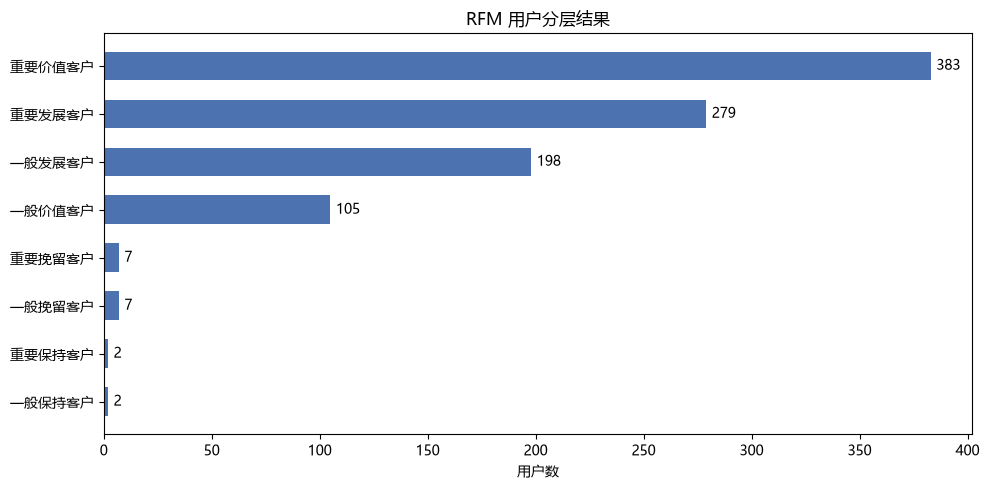

In [7]:
# 分层柱状图
counts = rfm['label'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(counts.index, counts.values, color='#4C72B0', height=0.6)
ax.bar_label(bars, padding=4)
ax.set_xlabel('用户数')
ax.set_title('RFM 用户分层结果')
plt.tight_layout()
plt.savefig(r"C:\Users\wukeyu31434\data-analyst-projects\taobao-user-behavior-analysis\reports\rfm_segments.png", dpi=150)
plt.show()

## 报告

完整业务解读（R 维度塌缩、分层运营动作、模型局限与改进）见 `reports/rfm_insights.md`。